In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Experiment 2.1: Running thermoelectric module in heat pump mode

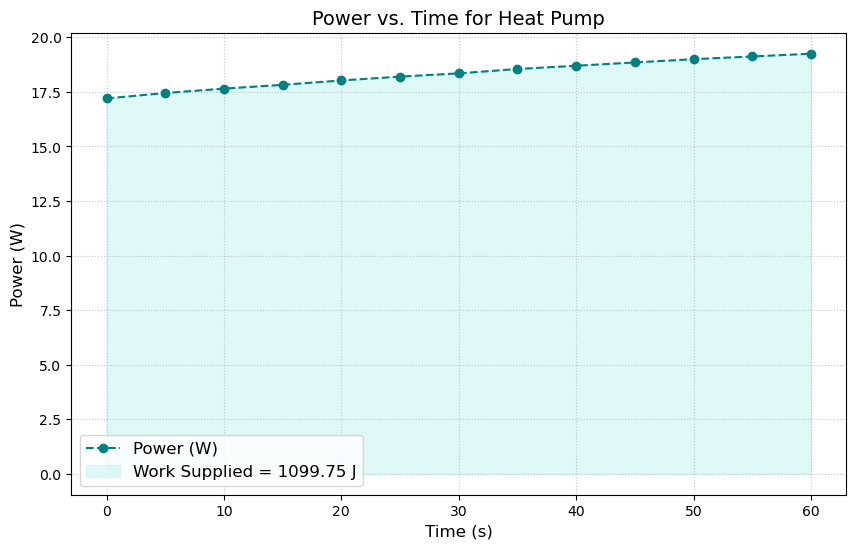

Total Work Supplied (Area under curve): 1099.75 Joules


In [7]:
# 1. Read the CSV data
df = pd.read_csv('V vs t for heat pump.csv')

# 2. Calculate Power (P = IV)
current_A = 2.5
df['power'] = df['voltage'] * current_A

# 3. Calculate Work Supplied (Area under the curve - using trapezium rule of integration)
work_supplied = np.trapz(df['power'], df['time'])

# 4. Plotting the data
plt.figure(figsize=(10, 6))

# Plot power vs time
plt.plot(df['time'], df['power'], marker='o', linestyle='--', color='teal', label='Power (W)')

# Fill the area under the curve for visual clarity
plt.fill_between(df['time'], df['power'], color='paleturquoise', alpha=0.4, 
                 label=f'Work Supplied = {work_supplied:.2f} J')

# Formatting the graph
plt.title('Power vs. Time for Heat Pump', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Power (W)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

# Show the plot and print the integral result
plt.show()

print(f"Total Work Supplied (Area under curve): {work_supplied:.2f} Joules")

## 2.2 continued: Running in heat engine mode:

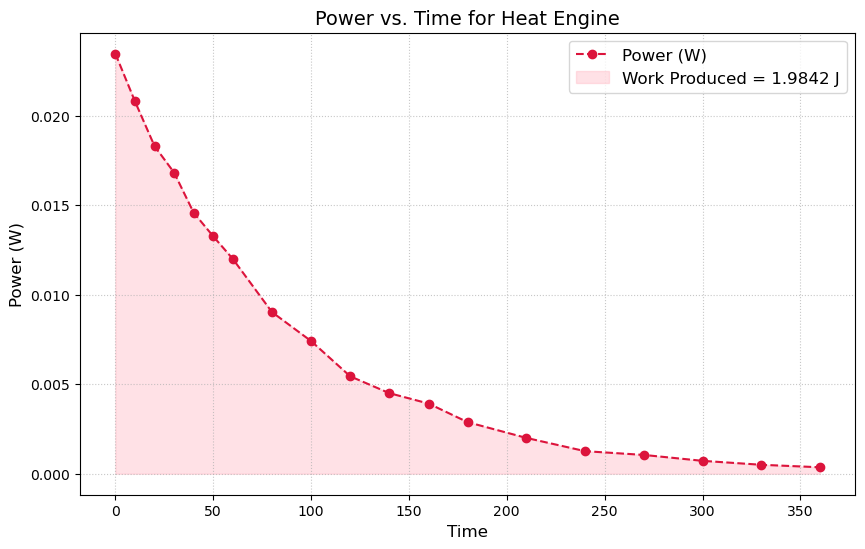

Total Work Produced (Area under curve): 1.9842 Joules


In [12]:
df = pd.read_csv('V vs t for heat engine.csv')
df['power'] = df['voltage'] * df['current']

work_produced = np.trapz(df['power'], df['time'])

plt.figure(figsize=(10, 6))

# Using 'crimson' to visually distinguish the heat engine from the heat pump graph (light blue)
plt.plot(df['time'], df['power'], marker='o', linestyle='--', color='crimson', label='Power (W)')

# Fill the area under the curve
plt.fill_between(df['time'], df['power'], color='lightpink', alpha=0.4, 
                 label=f'Work Produced = {work_produced:.4f} J')

# Formatting the graph
plt.title('Power vs. Time for Heat Engine', fontsize=14)
plt.xlabel('Time', fontsize=12) 
plt.ylabel('Power (W)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

plt.show()

print(f"Total Work Produced (Area under curve): {work_produced:.4f} Joules")

## Experiment 2.3: Testing efficiency for varying load resistors

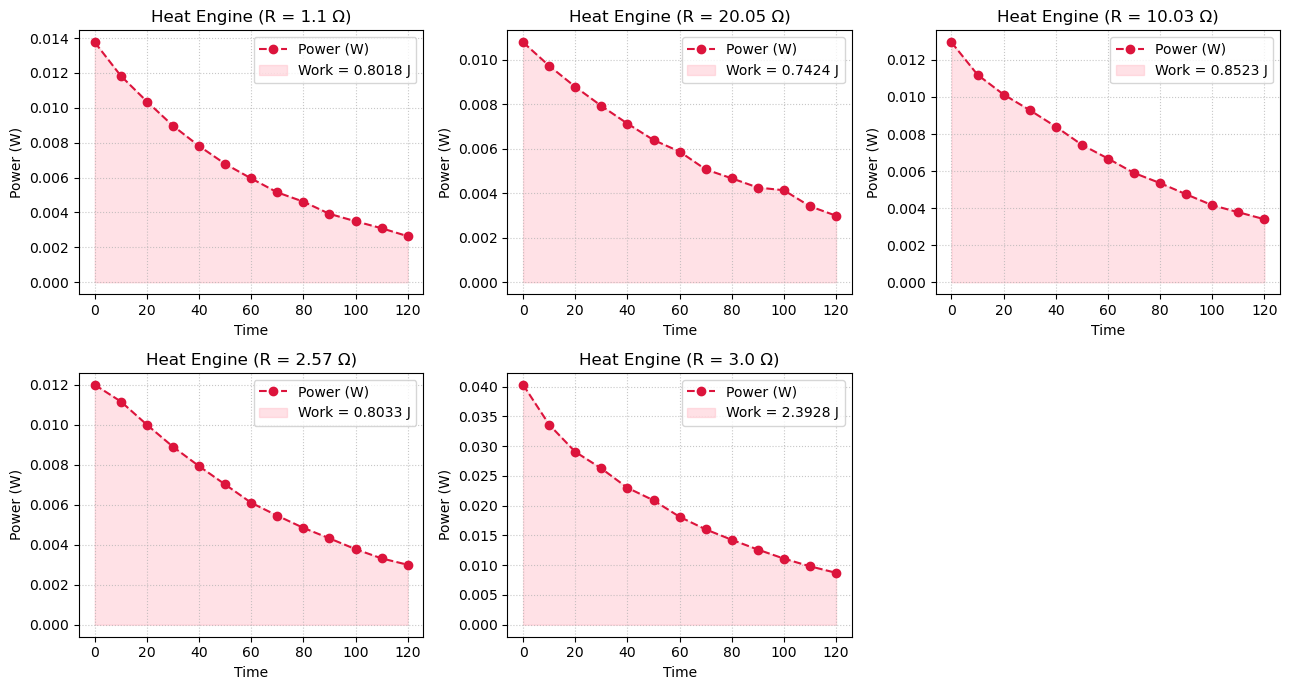

---------------------------------------------
TOTAL WORK PRODUCED PER LOAD RESISTANCE
---------------------------------------------
Resistance:  1.10 Ω   |   Work: 0.8018 Joules
Resistance: 20.05 Ω   |   Work: 0.7424 Joules
Resistance: 10.03 Ω   |   Work: 0.8523 Joules
Resistance:  2.57 Ω   |   Work: 0.8033 Joules
Resistance:  3.00 Ω   |   Work: 2.3928 Joules
---------------------------------------------


In [18]:
# 1. Read the multiple-resistor CSV data
df = pd.read_csv('5 resistors heat engine data.csv')

# Time is the very first column (index 0)
time = df.iloc[:, 0]

# The list of resistance values
resistances = [1.1, 20.05, 10.03, 2.57, 3.00]

# 2. Create a figure with a 2x3 grid (2 rows, 3 columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(13, 7))

# Flatten the 2D array of axes into a 1D list so it's easier to loop through
axes_flat = axes.flatten()

# Dictionary to store the integral results for printing later
work_results = {}

# 3. Loop through each resistance and build the subplots
for i, R in enumerate(resistances):
    # Calculate column positions in the CSV
    v_col = 1 + (i * 2)
    i_col = 2 + (i * 2)
    
    # Extract voltage and current
    voltage = df.iloc[:, v_col]
    current = df.iloc[:, i_col]
    
    
    power = voltage * current
    
    work_produced = np.trapz(power, time)
 
    work_results[R] = work_produced

    ax = axes_flat[i]
 
    ax.plot(time, power, marker='o', linestyle='--', color='crimson', label='Power (W)')
    
    ax.fill_between(time, power, color='lightpink', alpha=0.4, 
                    label=f'Work = {work_produced:.4f} J')
    
    # Formatting the graph
    ax.set_title(f'Heat Engine (R = {R} Ω)', fontsize=12) 
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel('Power (W)', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(fontsize=10)

# 4. Hide the 6th (empty) subplot at the bottom right
axes_flat[5].axis('off')

plt.tight_layout()
plt.show()

print("-" * 45)
print("TOTAL WORK PRODUCED PER LOAD RESISTANCE")
print("-" * 45)
for R, work in work_results.items():
    # Format the print statement so everything aligns nicely
    print(f"Resistance: {R:5.2f} Ω   |   Work: {work:.4f} Joules")
print("-" * 45)

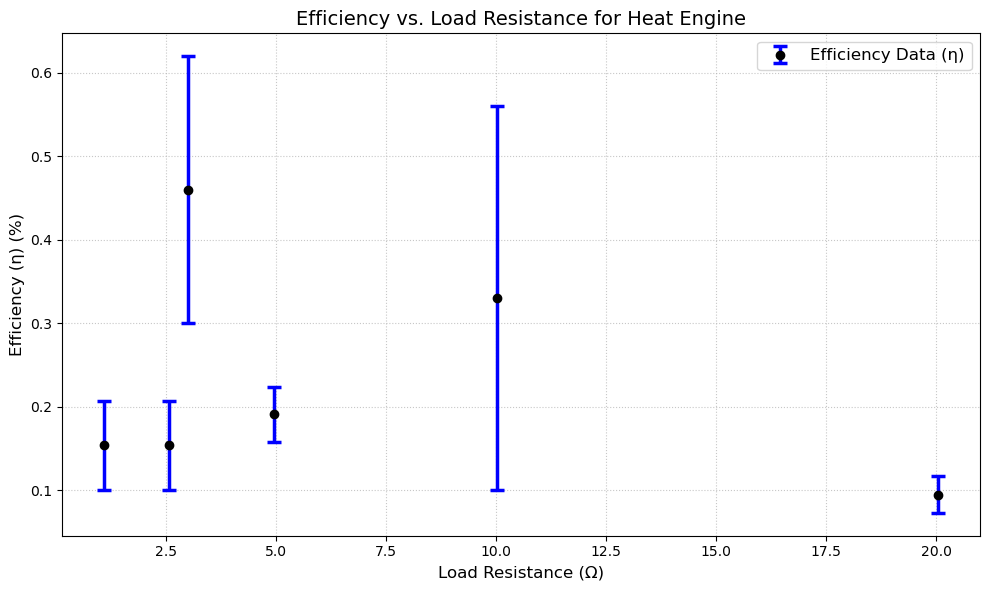

In [20]:
# Data: Resistance (Ω), Efficiency (η) (%), Uncertainty (%)
#These values were calculated in my lab book, using code above and then further calculations
resistance = np.array([1.1, 20.05, 10.03, 2.57, 3.00, 4.96])
efficiency = np.array([0.154, 0.095, 0.33, 0.154, 0.46, 0.191])
uncertainty = np.array([0.053, 0.022, 0.23, 0.053, 0.16, 0.033])

#Sort the data by resistance 
sorted_indices = np.argsort(resistance)
res_sorted = resistance[sorted_indices]
eff_sorted = efficiency[sorted_indices]
unc_sorted = uncertainty[sorted_indices]

#Plotting the data
plt.figure(figsize=(10, 6))
plt.errorbar(res_sorted, eff_sorted, yerr=unc_sorted, fmt='o', 
             color='black', ecolor='blue', elinewidth=2.5, capsize=5, capthick=2.5,
             label='Efficiency Data (η)')

# Formatting the graph
plt.title('Efficiency vs. Load Resistance for Heat Engine', fontsize=14)
plt.xlabel('Load Resistance (Ω)', fontsize=12)
plt.ylabel('Efficiency (η) (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

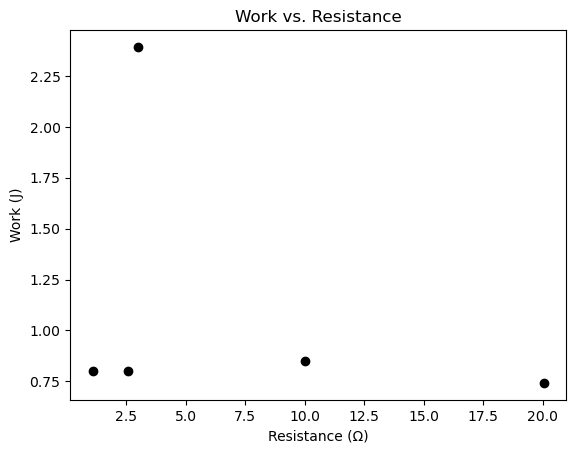

In [22]:
# Now plotting just resistance vs Work (assuming similar heat flows for all - therefore 
# work output is proxy for efficiency
plt.scatter([1.1, 20.05, 10.03, 2.57, 3.0], [0.8018, 0.7424, 0.8523, 0.8033, 2.3928], color='black')
plt.title('Work vs. Resistance'), plt.xlabel('Resistance (Ω)'), plt.ylabel('Work (J)')
plt.show()